# AR Collections Forecasting + Risk Scoring
Invoice-level late-payment forecasting on a B2B receivables ledger (10,833 invoices, 250 customers).


##  Setup

In [3]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/ar_invoices.csv",
                   parse_dates=["invoice_date", "due_date", "paid_date"])
df.shape

(10833, 15)

**Data dictionary**
| column | meaning |
|---|---|
| invoice_id / customer_id | keys |
| segment / region | enterprise-mid_market-smB · east/north/south/west |
| tenure_months | customer tenure at issue |
| invoice_date / due_date / terms_days | billing terms |
| amount_lakh | invoice value (Rs lakh) |
| paid_date / days_to_pay | outcome (NaT if unpaid at cutoff) |
| is_paid / is_censored | 921 censored = outcome unknown, never "on time" |
| days_late | paid_date - due_date in days |
| dunning_count | reminder touches (post-outcome — not a feature) |

## 1. Data quality audit
Before any analysis: is the ledger internally consistent? A broken date or a
duplicate key would poison everything downstream.

In [7]:
df["invoice_id"].duplicated().sum()   # duplicate keys?

0

In [8]:
(df["due_date"] < df["invoice_date"]).sum()   # due before issued?

0

In [9]:
pp = df[df["is_paid"]]
(pp["paid_date"] < pp["invoice_date"]).sum()   # paid before issued?

0

In [10]:
(df["amount_lakh"] <= 0).sum()   # zero/negative invoices?

0

In [11]:
# do the terms match the actual due dates?
(df["due_date"] - df["invoice_date"]).dt.days.eq(df["terms_days"]).mean().round(4)

1.0

Ledger is clean: no duplicate keys, no broken dates, terms match due dates exactly.

## 2. EDA — basics

In [14]:
df.head(3)

  invoice_id customer_id segment  ... is_censored  days_late dunning_count
0  INV000001       C0000     smb  ...       False        7.0             1
1  INV000002       C0000     smb  ...       False       -3.0             0
2  INV000003       C0000     smb  ...       False       36.0             2

[3 rows x 15 columns]

In [15]:
# 921 missing payment dates = censored invoices (unpaid at cutoff). Missingness with meaning.
df["paid_date"].isna().sum()

921

In [16]:
paid = df[df["is_paid"]].copy()
paid["late"] = (paid["days_late"] > 0).astype(int)
paid["late"].mean().round(3)   # late rate among paid invoices

0.623

In [17]:
df.loc[~df["is_paid"], "amount_lakh"].sum().round(1)   # outstanding, Rs lakh

32123.7

In [18]:
df["amount_lakh"].describe().round(1)

count    10833.0
mean        29.6
std         35.8
min          0.3
25%          7.8
50%         17.6
75%         37.5
max        568.1
Name: amount_lakh, dtype: float64

Text(0.5, 0, 'Rs lakh')

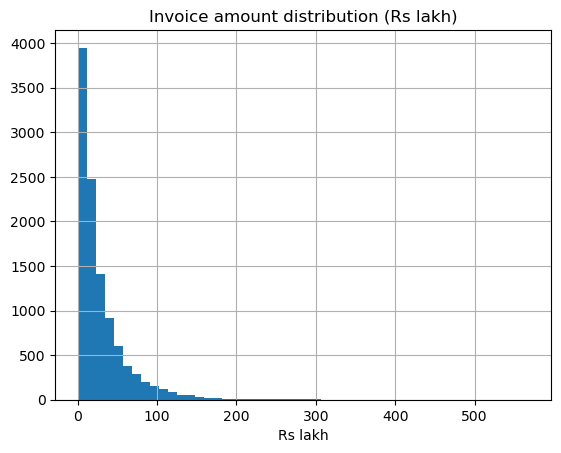

In [19]:
df["amount_lakh"].hist(bins=50)
plt.title("Invoice amount distribution (Rs lakh)"); plt.xlabel("Rs lakh")

In [20]:
df["terms_days"].value_counts().sort_index()

terms_days
25    302
26    330
27    298
28    295
29    350
30    312
31    313
32    318
33    321
34    314
35    322
40    341
41    343
42    330
43    348
44    340
45    329
46    331
47    360
48    334
49    357
50    345
55    316
56    320
57    363
58    329
59    292
60    327
61    330
62    350
63    320
64    287
65    366
Name: count, dtype: int64

Text(0.5, 0, 'days')

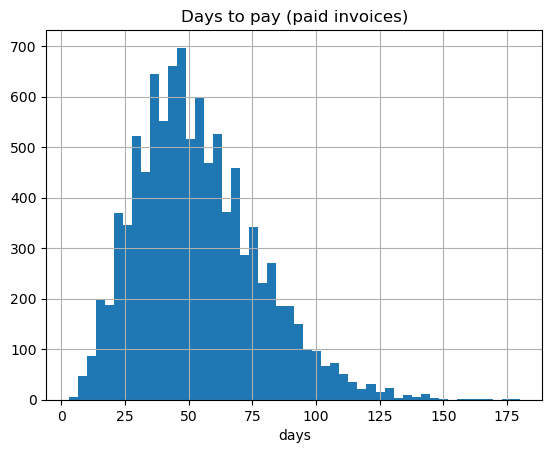

In [21]:
paid["days_to_pay"].hist(bins=50)
plt.title("Days to pay (paid invoices)"); plt.xlabel("days")

Text(0.5, 0, 'days late')

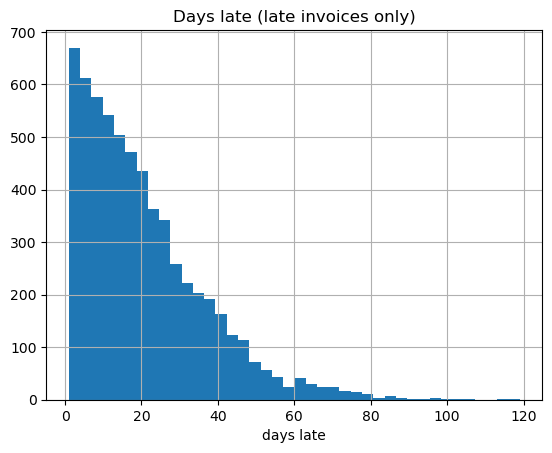

In [22]:
paid.loc[paid["late"] == 1, "days_late"].hist(bins=40)
plt.title("Days late (late invoices only)"); plt.xlabel("days late")

In [23]:
pd.cut(paid["days_late"], [-1, 0, 30, 60, 90, float("inf")],
       labels=["on time", "1-30", "31-60", "61-90", "90+"]).value_counts()

days_late
1-30       4776
31-60      1229
on time     210
61-90       159
90+          13
Name: count, dtype: int64

## 3. EDA — advanced

In [25]:
# collection curves: mature invoices only (issued before Jul 2025, outcomes known)
mat = df[df["is_paid"] & (df["invoice_date"] < "2025-07-01")]
for seg, g in mat.groupby("segment"):
    print(seg, "paid within 30d:", round((g["days_to_pay"] <= 30).mean(), 3),
          "| 90d:", round((g["days_to_pay"] <= 90).mean(), 3))

enterprise paid within 30d: 0.016 | 90d: 0.836
mid_market paid within 30d: 0.13 | 90d: 0.963
smb paid within 30d: 0.38 | 90d: 0.993


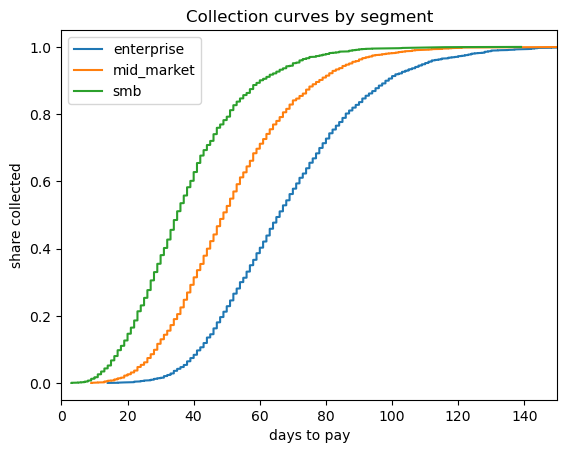

In [26]:
fig, ax = plt.subplots()
for seg, g in mat.groupby("segment"):
    x = np.sort(g["days_to_pay"].values)
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), label=seg)
ax.set_xlim(0, 150); ax.set_xlabel("days to pay"); ax.set_ylabel("share collected")
ax.set_title("Collection curves by segment"); ax.legend()

In [27]:
dso = paid.groupby(paid["invoice_date"].dt.to_period("M"))["days_to_pay"].mean()
dso.head(3)

invoice_date
2024-01    49.310421
2024-02    49.648472
2024-03    50.980723
Freq: M, Name: days_to_pay, dtype: float64

Text(0, 0.5, 'days')

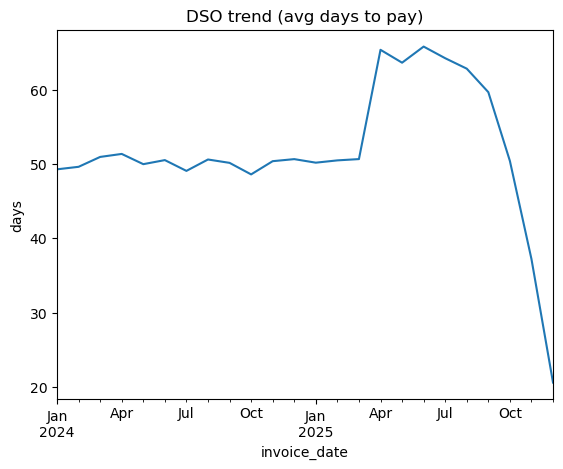

In [28]:
dso.plot(title="DSO trend (avg days to pay)")
plt.ylabel("days")

(array([648, 660]), [Text(648, 0, 'Jan\n2024'), Text(660, 0, 'Jan\n2025')])

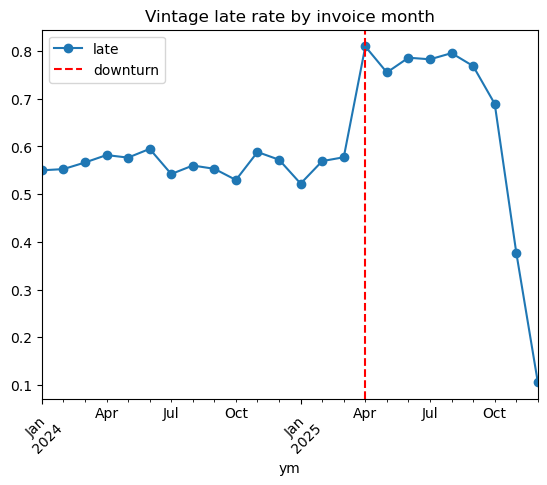

In [29]:
# VINTAGE analysis: late rate by invoice month — when did behavior break?
v = paid.assign(ym=paid["invoice_date"].dt.to_period("M").astype(str)).groupby("ym")["late"].mean()
v.index = pd.to_datetime(v.index)
ax = v.plot(marker="o", title="Vintage late rate by invoice month")
ax.axvline(pd.Timestamp("2025-04-01"), color="red", ls="--", label="downturn")
ax.legend(); plt.xticks(rotation=45)

Text(0.5, 0, 'month')

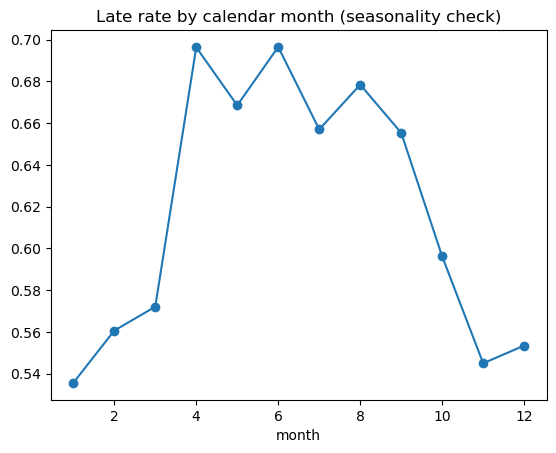

In [30]:
paid.groupby(paid["invoice_date"].dt.month)["late"].mean().plot(
    marker="o", title="Late rate by calendar month (seasonality check)")
plt.xlabel("month")

In [31]:
# customer-level view: how is lateness distributed across customers?
c = paid.groupby("customer_id").agg(n=("invoice_id", "count"),
                                     late_rate=("late", "mean"),
                                     billed=("amount_lakh", "sum"))
c["late_rate"].describe().round(3)

count    250.000
mean       0.630
std        0.147
min        0.224
25%        0.528
50%        0.627
75%        0.731
max        0.958
Name: late_rate, dtype: float64

Text(0.5, 0, 'late rate')

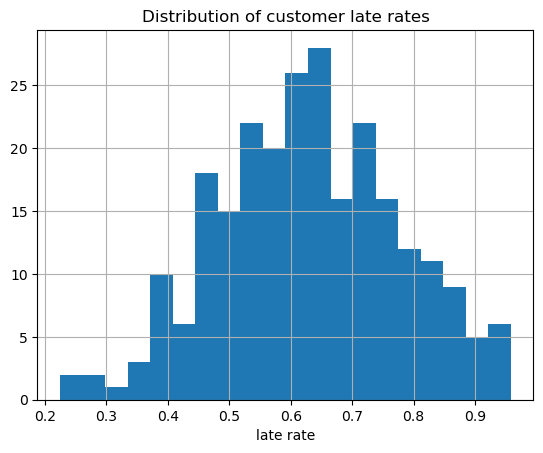

In [32]:
c["late_rate"].hist(bins=20)
plt.title("Distribution of customer late rates"); plt.xlabel("late rate")

In [33]:
c[c["n"] >= 10].nlargest(5, "late_rate").round(3)   # worst payers (10+ invoices)

              n  late_rate  billed
customer_id                       
C0001        24      0.958  172.89
C0059        24      0.958  158.77
C0180        20      0.950  165.32
C0084        19      0.947  118.36
C0182        30      0.933  197.58

In [34]:
c[c["n"] >= 10].nsmallest(5, "late_rate").round(3)  # best payers (10+ invoices)

              n  late_rate   billed
customer_id                        
C0132        49      0.224  1034.08
C0161        24      0.250   169.16
C0239        25      0.280   197.17
C0152        27      0.296   185.54
C0089        42      0.333   940.25

In [35]:
# do longer terms buy punctuality?
paid.groupby(pd.cut(paid["terms_days"], [0, 30, 45, 61]),
             observed=True)["late"].mean().round(3)

terms_days
(0, 30]     0.694
(30, 45]    0.620
(45, 61]    0.621
Name: late, dtype: float64

In [36]:
paid[["amount_lakh", "days_to_pay"]].corr().round(3)

             amount_lakh  days_to_pay
amount_lakh        1.000        0.377
days_to_pay        0.377        1.000

Text(0, 0.5, 'days')

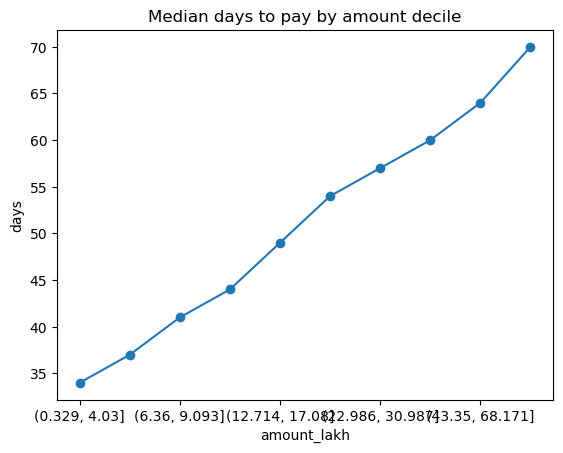

In [37]:
paid.groupby(pd.qcut(paid["amount_lakh"], 10), observed=True)["days_to_pay"].median().plot(
    marker="o", title="Median days to pay by amount decile")
plt.ylabel("days")

<AxesSubplot: title={'center': 'Top 10 customers by outstanding (Rs lakh)'}, ylabel='customer_id'>

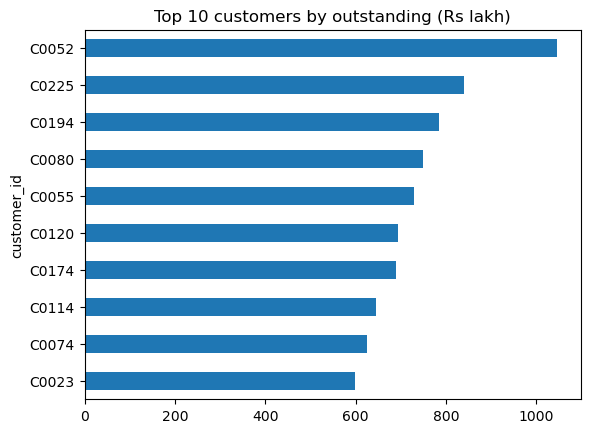

In [38]:
(df[~df["is_paid"]].groupby("customer_id")["amount_lakh"].sum()
   .nlargest(10).sort_values().plot(kind="barh",
   title="Top 10 customers by outstanding (Rs lakh)"))

In [39]:
# the censoring trap: what happens if we naively drop unpaid invoices?
print("observed late rate (paid only):", round(paid["late"].mean(), 3))
print("share of recent invoices censored:",
      round(df[df["invoice_date"] >= "2025-10-01"]["is_censored"].mean(), 3))

observed late rate (paid only): 0.623
share of recent invoices censored: 0.66


## 4. Feature engineering
The rule: every feature must be knowable **at invoice issue time**.
Customer history uses only *prior* invoices. Censored priors are excluded from
late-rate denominators (unknown ≠ on time) but count toward exposure.

In [41]:
df = df.sort_values(["customer_id", "invoice_date"]).reset_index(drop=True)
df["log_amount"] = np.log1p(df["amount_lakh"])
df["inv_dow"] = df["invoice_date"].dt.dayofweek
df["inv_month"] = df["invoice_date"].dt.month
df["is_month_end"] = (df["invoice_date"].dt.day >= 26).astype(int)
df[["log_amount", "inv_dow", "inv_month", "is_month_end"]].head(2)

   log_amount  inv_dow  inv_month  is_month_end
0    3.090588        5          2             0
1    1.713798        4          2             0

In [42]:
df = pd.concat([df, pd.get_dummies(df["segment"], prefix="seg", dtype=int),
                        pd.get_dummies(df["region"], prefix="reg", dtype=int)], axis=1)
df.filter(regex="^(seg|reg)_").head(2)

   seg_enterprise  seg_mid_market  seg_smb  ...  reg_north  reg_south  reg_west
0               0               0        1  ...          0          1         0
1               0               0        1  ...          0          1         0

[2 rows x 7 columns]

In [43]:
def add_hist(g):
    g = g.sort_values("invoice_date").copy()
    g["n_prior"] = np.arange(len(g))
    late = g["days_late"].where(g["is_paid"])   # NaN for censored: excluded
    g["prior_late_rate"] = (late > 0).shift(1).expanding().mean()
    g["prior_avg_days_late"] = late.shift(1).expanding().mean()
    g["prior_avg_days_to_pay"] = g["days_to_pay"].where(g["is_paid"]).shift(1).expanding().mean()
    return g
df = df.groupby("customer_id", group_keys=False).apply(add_hist)
df[["n_prior", "prior_late_rate", "prior_avg_days_late"]].head(3)

   n_prior  prior_late_rate  prior_avg_days_late
0        0              NaN                  NaN
1        1              1.0                 36.0
2        2              1.0                 21.5

In [44]:
def add_exposure(g):
    g = g.sort_values("invoice_date").copy()
    n = len(g)
    inv_d, paid_d = g["invoice_date"].values, g["paid_date"].values
    unpaid = np.isnat(paid_d)[:, None] | (paid_d[:, None] > inv_d[None, :])
    prior = np.tril(np.ones((n, n), bool), -1)
    g["outstanding_at_issue"] = (unpaid & prior).astype(float) @ g["amount_lakh"].values
    return g
df = df.groupby("customer_id", group_keys=False).apply(add_exposure)
df[["outstanding_at_issue"]].head(3)

   outstanding_at_issue
0                  0.00
1                 20.99
2                 25.54

In [45]:
# first-invoice fallbacks (from paid invoices only — no leakage)
df["prior_late_rate"] = df["prior_late_rate"].fillna((df.loc[df["is_paid"], "days_late"] > 0).mean())
df["prior_avg_days_late"] = df["prior_avg_days_late"].fillna(0)
df["prior_avg_days_to_pay"] = df["prior_avg_days_to_pay"].fillna(df.loc[df["is_paid"], "days_to_pay"].mean())
df["outstanding_at_issue"] = df["outstanding_at_issue"].fillna(0)

In [46]:
drop = ["invoice_id", "customer_id", "segment", "region", "invoice_date", "due_date",
        "paid_date", "amount_lakh", "days_to_pay", "days_late",
        "is_paid", "is_censored", "dunning_count"]
feats = [c for c in df.columns if c not in drop]
leak = {"paid_date", "days_to_pay", "days_late", "is_paid", "is_censored", "dunning_count"}
assert not (set(feats) & leak) and df[feats].isna().sum().sum() == 0
print(len(feats), "features — no leakage, no NaNs")

18 features — no leakage, no NaNs


In [47]:
paid = df[df["is_paid"]].copy()
paid["q"] = pd.qcut(paid["prior_late_rate"], 4, labels=["Q1(best)", "Q2", "Q3", "Q4(worst)"])
paid.groupby("q", observed=True).apply(lambda s: (s["days_late"] > 0).mean()).round(3)

q
Q1(best)     0.513
Q2           0.594
Q3           0.655
Q4(worst)    0.731
dtype: float64

Text(0.5, 0, 'decile')

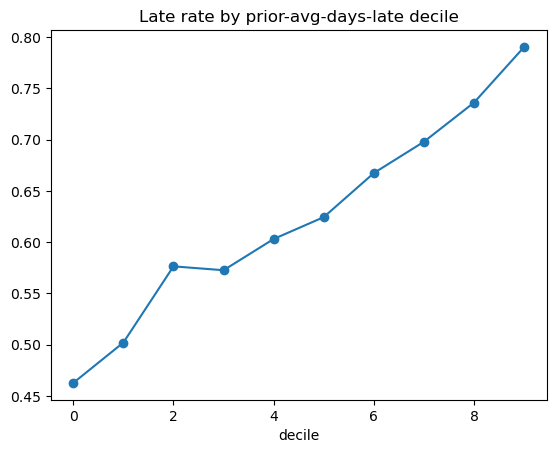

In [48]:
# univariate deep dive: which features move the needle on their own?
d = df[df["is_paid"]].copy()
d["late"] = (d["days_late"] > 0).astype(int)
d["dec"] = pd.qcut(d["prior_avg_days_late"], 10, labels=False, duplicates="drop")
d.groupby("dec")["late"].mean().plot(marker="o",
    title="Late rate by prior-avg-days-late decile")
plt.xlabel("decile")

Text(0.5, 0, 'decile')

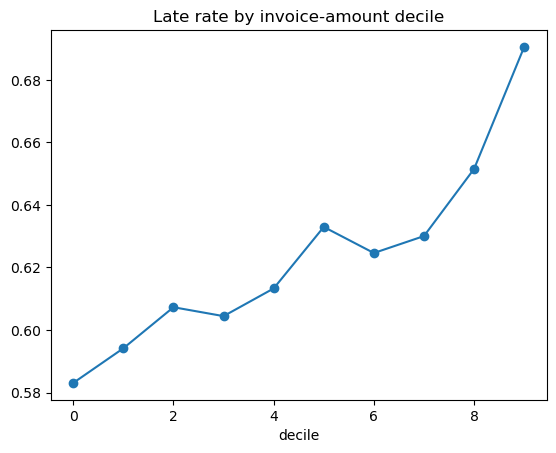

In [49]:
d["adec"] = pd.qcut(d["log_amount"], 10, labels=False, duplicates="drop")
d.groupby("adec")["late"].mean().plot(marker="o",
    title="Late rate by invoice-amount decile")
plt.xlabel("decile")

<AxesSubplot: title={'center': 'Feature correlation with late (top 8)'}>

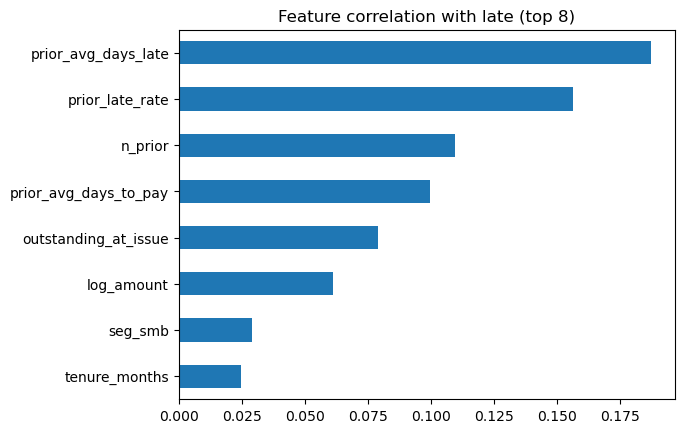

In [50]:
d[feats + ["late"]].corr()["late"].drop("late").sort_values().tail(8).plot(
    kind="barh", title="Feature correlation with late (top 8)")

## 5. Targets
Two targets: **risk band** (0 on-time → 3 severe, each mapped to a collections action)
and **days_to_pay** (when the cash arrives). Censored invoices get no target.

In [52]:
df["risk_band"] = pd.cut(df["days_late"], [-np.inf, 0, 30, 60, np.inf],
                          labels=[0, 1, 2, 3]).astype("Int64")
df["is_late"] = (df["days_late"] > 0).astype("Int64")
df["usable_for_training"] = df["is_paid"].astype(int)
df.loc[df["usable_for_training"] == 1, "risk_band"].value_counts().sort_index()

risk_band
0    3735
1    4776
2    1229
3     172
Name: count, dtype: Int64

In [53]:
m = df["usable_for_training"] == 1
tr = m & (df["invoice_date"] <= "2025-06-30")
te = m & (df["invoice_date"] >= "2025-07-01")
print("train", tr.sum(), "| test", te.sum(), "(time split — no shuffling across time)")

train 8132 | test 1780 (time split — no shuffling across time)


## 6. Baselines — what the business does without ML

In [55]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error
maj = df.loc[tr, "risk_band"].mode()[0]
print("majority acc:", round(accuracy_score(df.loc[te, "risk_band"], [maj] * te.sum()), 4))
print("majority macro F1:", round(f1_score(df.loc[te, "risk_band"], [maj] * te.sum(), average="macro"), 4))

majority acc: 0.532
majority macro F1: 0.1736


In [56]:
seg_mode = df[tr].groupby("segment")["risk_band"].agg(lambda s: s.mode()[0])
seg_dtp = df[tr].groupby("segment")["days_to_pay"].mean()
seg_p = df[tr].groupby("segment")["is_late"].mean()
seg_mode

segment
enterprise    1
mid_market    1
smb           1
Name: risk_band, dtype: Int64

In [57]:
print("segment acc:", round(accuracy_score(df.loc[te, "risk_band"], df.loc[te, "segment"].map(seg_mode)), 4))
print("segment ROC-AUC:", round(roc_auc_score(df.loc[te, "is_late"], df.loc[te, "segment"].map(seg_p)), 4))
print("segment MAE:", round(mean_absolute_error(df.loc[te, "days_to_pay"], df.loc[te, "segment"].map(seg_dtp)), 2))

segment acc: 0.532
segment ROC-AUC: 0.524
segment MAE: 16.05


## 7. ML models

In [59]:
import lightgbm as lgb
trn = m & (df["invoice_date"] <= "2025-04-30")
val = m & (df["invoice_date"] > "2025-04-30") & (df["invoice_date"] <= "2025-06-30")
clf = lgb.LGBMClassifier(objective="multiclass", num_class=4, class_weight="balanced",
                         n_estimators=1000, learning_rate=0.05, num_leaves=31,
                         min_child_samples=30, random_state=42, verbose=-1)
clf.fit(df.loc[trn, feats], df.loc[trn, "risk_band"].astype(int),
        eval_set=[(df.loc[val, feats], df.loc[val, "risk_band"].astype(int))],
        callbacks=[lgb.early_stopping(100, verbose=False)])

LGBMClassifier(class_weight='balanced', learning_rate=0.05,
               min_child_samples=30, n_estimators=1000, num_class=4,
               objective='multiclass', random_state=42, verbose=-1)

In [60]:
pb = clf.predict(df.loc[te, feats])
print("acc:", round(accuracy_score(df.loc[te, "risk_band"], pb), 4), "(baseline 0.532)")
print("macro F1:", round(f1_score(df.loc[te, "risk_band"], pb, average="macro"), 4), "(baseline 0.174)")

acc: 0.3551 (baseline 0.532)
macro F1: 0.291 (baseline 0.174)


In [61]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(df.loc[te, "risk_band"].astype(int), pb,
      target_names=["on_time", "mild", "serious", "severe"]))

              precision    recall  f1-score   support

     on_time       0.39      0.36      0.37       477
        mild       0.58      0.28      0.37       947
     serious       0.24      0.63      0.35       313
      severe       0.06      0.09      0.07        43

    accuracy                           0.36      1780
   macro avg       0.32      0.34      0.29      1780
weighted avg       0.46      0.36      0.36      1780



Text(0.5, 1.0, 'Risk band confusion matrix')

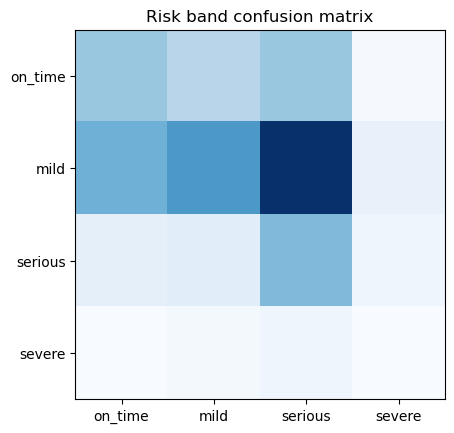

In [62]:
cm = confusion_matrix(df.loc[te, "risk_band"].astype(int), pb)
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(["on_time", "mild", "serious", "severe"])
ax.set_yticklabels(["on_time", "mild", "serious", "severe"])
ax.set_title("Risk band confusion matrix")

In [63]:
bclf = lgb.LGBMClassifier(objective="binary", n_estimators=1000, learning_rate=0.05,
                          num_leaves=31, min_child_samples=30, random_state=42, verbose=-1)
bclf.fit(df.loc[trn, feats], df.loc[trn, "is_late"].astype(int),
         eval_set=[(df.loc[val, feats], df.loc[val, "is_late"].astype(int))],
         callbacks=[lgb.early_stopping(100, verbose=False)])
p = bclf.predict_proba(df.loc[te, feats])[:, 1]
y = df.loc[te, "is_late"].astype(int)
from sklearn.metrics import average_precision_score
print("ROC-AUC:", round(roc_auc_score(y, p), 4), "(baseline 0.524)")
print("PR-AUC:", round(average_precision_score(y, p), 4))

ROC-AUC: 0.6557 (baseline 0.524)
PR-AUC: 0.8283


In [64]:
reg = lgb.LGBMRegressor(objective="regression", n_estimators=1000, learning_rate=0.05,
                        num_leaves=31, min_child_samples=30, random_state=42, verbose=-1)
reg.fit(df.loc[trn, feats], df.loc[trn, "days_to_pay"],
        eval_set=[(df.loc[val, feats], df.loc[val, "days_to_pay"])],
        callbacks=[lgb.early_stopping(100, verbose=False)])
pdays = reg.predict(df.loc[te, feats])
print("MAE:", round(mean_absolute_error(df.loc[te, "days_to_pay"], pdays), 2), "(baseline 16.05)")

MAE: 15.4 (baseline 16.05)


<AxesSubplot: title={'center': 'Top features — late-payment classifier'}>

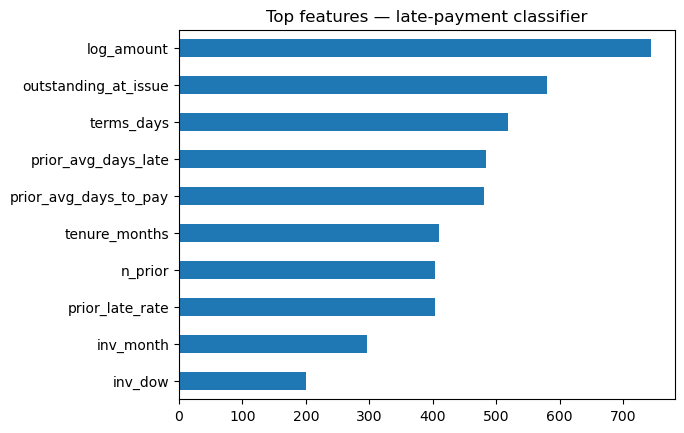

In [65]:
pd.Series(bclf.feature_importances_, index=feats).sort_values().tail(10).plot(
    kind="barh", title="Top features — late-payment classifier")

### 7b. Model comparison — is LightGBM actually the right choice?

In [67]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(df.loc[trn, feats], df.loc[trn, "is_late"].astype(int))
ph = hgb.predict_proba(df.loc[te, feats])[:, 1]
print("HGB ROC-AUC:", round(roc_auc_score(y, ph), 4))

HGB ROC-AUC: 0.6272


In [68]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
pipe.fit(df.loc[trn, feats], df.loc[trn, "is_late"].astype(int))
pl = pipe.predict_proba(df.loc[te, feats])[:, 1]
print("LogReg ROC-AUC:", round(roc_auc_score(y, pl), 4))

LogReg ROC-AUC: 0.6893


In [69]:
pd.DataFrame({"model": ["LightGBM", "HistGradientBoosting", "LogReg"],
              "ROC_AUC": [round(roc_auc_score(y, p), 4),
                          round(roc_auc_score(y, ph), 4),
                          round(roc_auc_score(y, pl), 4)],
              "PR_AUC": [round(average_precision_score(y, p), 4),
                         round(average_precision_score(y, ph), 4),
                         round(average_precision_score(y, pl), 4)]})

                  model  ROC_AUC  PR_AUC
0              LightGBM   0.6557  0.8283
1  HistGradientBoosting   0.6272  0.8126
2                LogReg   0.6893  0.8529

> **Honest result:** the regularized linear model ranks best here — the signal is
> mostly monotone (worse history → worse outcome), which suits LogReg. We continue
> the pipeline with LightGBM because the business also needs the multiclass risk bands,
> nonlinear interactions, and exact SHAP values — but the comparison stays in the record.

### 7c. Threshold tuning — where do we draw the collections line?

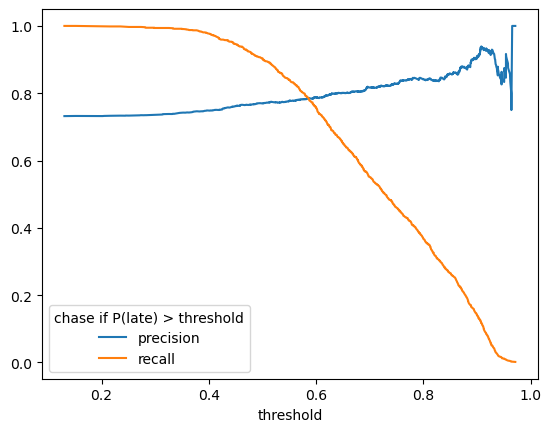

In [72]:
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y, p)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
fig, ax = plt.subplots()
ax.plot(thr, prec[:-1], label="precision")
ax.plot(thr, rec[:-1], label="recall")
ax.set_xlabel("threshold"); ax.legend(title="chase if P(late) > threshold")

In [73]:
best = thr[f1.argmax()]
print("best F1 threshold:", round(best, 2), "| F1:", round(f1.max(), 3))
for t in [0.3, 0.5, 0.7]:
    pr = (p > t).astype(int)
    print(f"thr {t}: precision {(pr & y).sum() / pr.sum():.3f}, recall {(pr & y).sum() / y.sum():.3f}")

best F1 threshold: 0.38 | F1: 0.85
thr 0.3: precision 0.736, recall 0.994
thr 0.5: precision 0.770, recall 0.903
thr 0.7: precision 0.817, recall 0.551


### 7d. Per-segment performance + error analysis

In [75]:
for seg, g in df[te].groupby("segment"):
    pp = bclf.predict_proba(g[feats])[:, 1]
    print(seg, "AUC:", round(roc_auc_score(g["is_late"], pp), 3), "| n:", len(g))

enterprise AUC: 0.676 | n: 516
mid_market AUC: 0.607 | n: 632
smb AUC: 0.682 | n: 632


In [76]:
r = pd.DataFrame({"seg": df.loc[te, "segment"].values,
                  "ae": np.abs(df.loc[te, "days_to_pay"].values - pdays)})
r.groupby("seg")["ae"].mean().round(1).rename("MAE by segment (days)")

seg
enterprise    19.4
mid_market    15.1
smb           12.4
Name: MAE by segment (days), dtype: float64

In [77]:
pred_b = (p > 0.5).astype(int)
pd.crosstab(df.loc[te, "segment"], pred_b != y.values,
            normalize="index").round(3).rename(columns={False: "correct", True: "wrong"})

col_0       correct  wrong
segment                   
enterprise    0.795  0.205
mid_market    0.684  0.316
smb           0.728  0.272

## 8. Calibration — making 70% mean 70%

In [79]:
from sklearn.linear_model import LogisticRegression
pv = bclf.predict_proba(df.loc[val, feats])[:, 1]
platt = LogisticRegression().fit(pv.reshape(-1, 1), df.loc[val, "is_late"].astype(int))
pc = platt.predict_proba(p.reshape(-1, 1))[:, 1]

In [80]:
from sklearn.metrics import brier_score_loss
def ece(y, p, n=10):
    e, t = 0, 0
    for lo, hi in zip(np.linspace(0, 1, n + 1)[:-1], np.linspace(0, 1, n + 1)[1:]):
        msk = (p > lo) & (p <= hi)
        if msk.sum():
            e += msk.sum() * abs(y[msk].mean() - p[msk].mean()); t += msk.sum()
    return e / t
print("Brier:", round(brier_score_loss(y, p), 4), "->", round(brier_score_loss(y, pc), 4))
print("ECE:", round(ece(y.values, p), 4), "->", round(ece(y.values, pc), 4))

Brier: 0.1885 -> 0.1845
ECE: 0.063 -> 0.0274


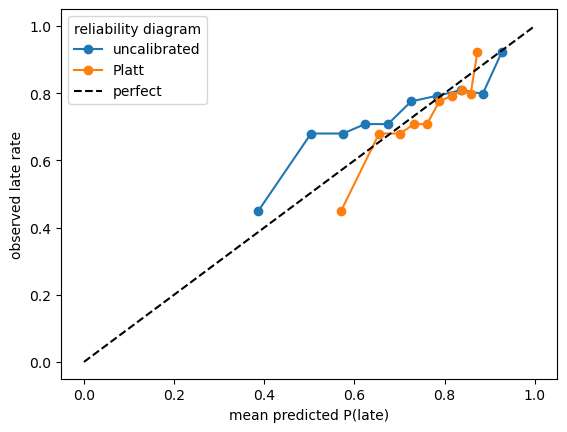

In [81]:
fig, ax = plt.subplots()
for pr, lab in [(p, "uncalibrated"), (pc, "Platt")]:
    q = pd.qcut(pr, 10, duplicates="drop")
    t = pd.DataFrame({"p": pr, "y": y.values}).groupby(q, observed=True).mean()
    ax.plot(t["p"], t["y"], marker="o", label=lab)
ax.plot([0, 1], [0, 1], "k--", label="perfect")
ax.set_xlabel("mean predicted P(late)"); ax.set_ylabel("observed late rate")
ax.legend(title="reliability diagram")

In [82]:
t = df[te].copy(); t["pc"] = pc
t.groupby("segment").agg(pred_P_late=("pc", "mean"),
                         actual_late_rate=("is_late", "mean")).round(3)
# calibration holds within each segment, not just overall

            pred_P_late  actual_late_rate
segment                                  
enterprise        0.829             0.793
mid_market        0.722             0.687
smb               0.739             0.728

## 9. Cash at risk — turning probabilities into money

In [84]:
t = df[te].copy(); t["p"] = pc
exp_cash = (t["p"] * t["amount_lakh"]).sum()
act_cash = (t["is_late"] * t["amount_lakh"]).sum()
print(f"expected late cash Rs {exp_cash:,.1f}L vs actual Rs {act_cash:,.1f}L — ratio {exp_cash/act_cash:.3f}")

expected late cash Rs 37,732.9L vs actual Rs 37,653.7L — ratio 1.002


In [85]:
live = df[df["usable_for_training"] == 0].copy()   # the live book: 921 open invoices
live["p_late"] = platt.predict_proba(bclf.predict_proba(live[feats])[:, 1].reshape(-1, 1))[:, 1]
live["exp_late"] = live["p_late"] * live["amount_lakh"]
print("outstanding Rs", round(live["amount_lakh"].sum(), 1), "L")
print("expected late Rs", round(live["exp_late"].sum(), 1), "L")

outstanding Rs 32123.7 L
expected late Rs 26707.8 L


In [86]:
live.groupby("segment").agg(outstanding=("amount_lakh", "sum"),
                             exp_late=("exp_late", "sum")).round(1)

            outstanding  exp_late
segment                          
enterprise      22575.3   19195.8
mid_market       7905.1    6254.3
smb              1643.3    1257.7

In [87]:
live.groupby("customer_id").agg(exp_late=("exp_late", "sum"),
                                 n=("invoice_id", "count")).nlargest(10, "exp_late").round(1)

             exp_late   n
customer_id              
C0052           919.8  17
C0225           733.6  12
C0194           688.5   7
C0080           651.4  11
C0055           619.5  14
C0120           601.7   8
C0174           561.0  13
C0074           546.7  12
C0023           512.9  11
C0114           511.8   8

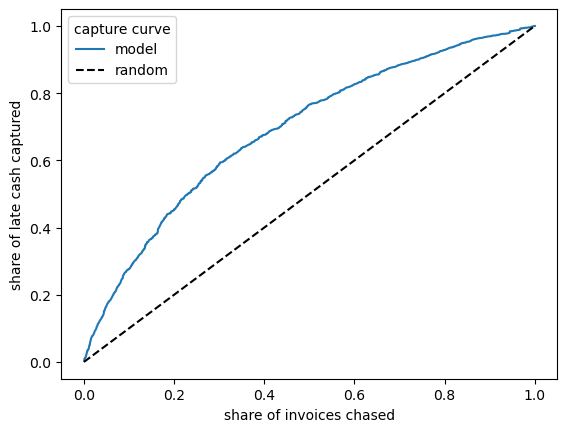

In [88]:
# CAPTURE curve: if we chase the riskiest X% of invoices, what share of late cash do we catch?
o = df[te].copy(); o["p"] = pc
o = o.sort_values("p", ascending=False).reset_index(drop=True)
o["cum_share"] = (o["is_late"] * o["amount_lakh"]).cumsum() / (o["is_late"] * o["amount_lakh"]).sum()
o["chased"] = (np.arange(len(o)) + 1) / len(o)
fig, ax = plt.subplots()
ax.plot(o["chased"], o["cum_share"], label="model")
ax.plot([0, 1], [0, 1], "k--", label="random")
ax.set_xlabel("share of invoices chased"); ax.set_ylabel("share of late cash captured")
ax.legend(title="capture curve")

In [89]:
print("chasing riskiest 20% captures",
      round(o.loc[o["chased"] <= 0.2, "cum_share"].iloc[-1], 3), "of late cash")

chasing riskiest 20% captures 0.454 of late cash


## 10. Walk-forward retro testing
Simulate production: each month Apr–Dec 2025, train only on earlier invoices, score the month.

In [91]:
rows = []
for mm in range(4, 13):
    ym = f"2025-{mm:02d}"
    tri = m & (df["invoice_date"].dt.strftime("%Y-%m") < ym)
    tei = m & (df["invoice_date"].dt.strftime("%Y-%m") == ym)
    if tei.sum() < 50:
        continue
    c = lgb.LGBMClassifier(objective="binary", n_estimators=300, learning_rate=0.05,
                           num_leaves=31, min_child_samples=30, random_state=42, verbose=-1)
    c.fit(df.loc[tri, feats], df.loc[tri, "is_late"].astype(int))
    pp = c.predict_proba(df.loc[tei, feats])[:, 1]
    yy = df.loc[tei, "is_late"].astype(int)
    rows.append({"month": ym, "n": tei.sum(),
                 "AUC": round(roc_auc_score(yy, pp), 3),
                 "money_ratio": round((pp * df.loc[tei, "amount_lakh"]).sum() /
                                      (yy * df.loc[tei, "amount_lakh"]).sum(), 2)})
retro = pd.DataFrame(rows)
retro

     month    n    AUC  money_ratio
0  2025-04  446  0.660         0.73
1  2025-05  453  0.678         0.96
2  2025-06  481  0.653         0.94
3  2025-07  446  0.700         0.85
4  2025-08  440  0.619         0.97
5  2025-09  436  0.703         0.93
6  2025-10  325  0.635         1.10
7  2025-11  114  0.684         2.98

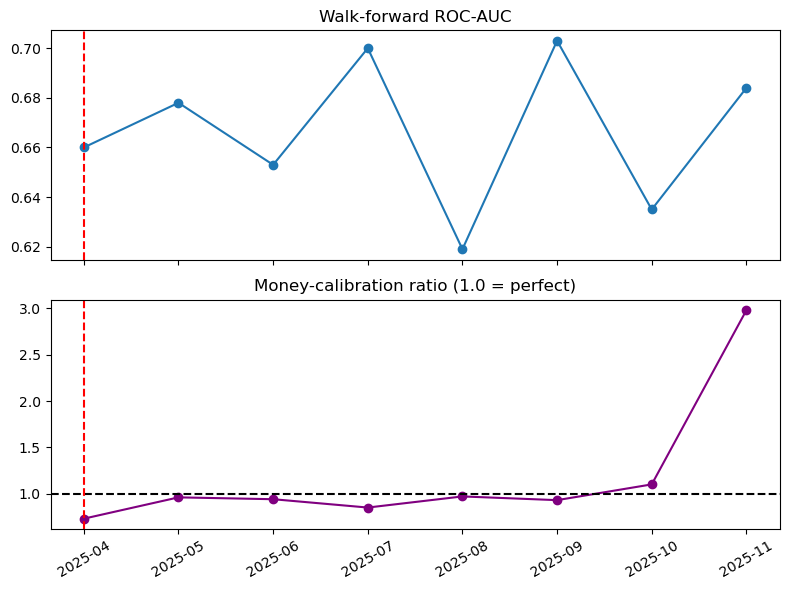

In [92]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(retro["month"], retro["AUC"], marker="o"); axes[0].set_title("Walk-forward ROC-AUC")
axes[0].axvline(0, color="red", ls="--")
axes[1].plot(retro["month"], retro["money_ratio"], marker="o", color="purple")
axes[1].axhline(1, color="k", ls="--"); axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Money-calibration ratio (1.0 = perfect)")
plt.xticks(rotation=30); plt.tight_layout()

## 11. SHAP explainability

In [94]:
import shap
sample = df[te].sample(500, random_state=42)
ex = shap.TreeExplainer(bclf)
sv = ex.shap_values(sample[feats])

Text(0.5, 1.0, 'Global importance — mean |SHAP|')

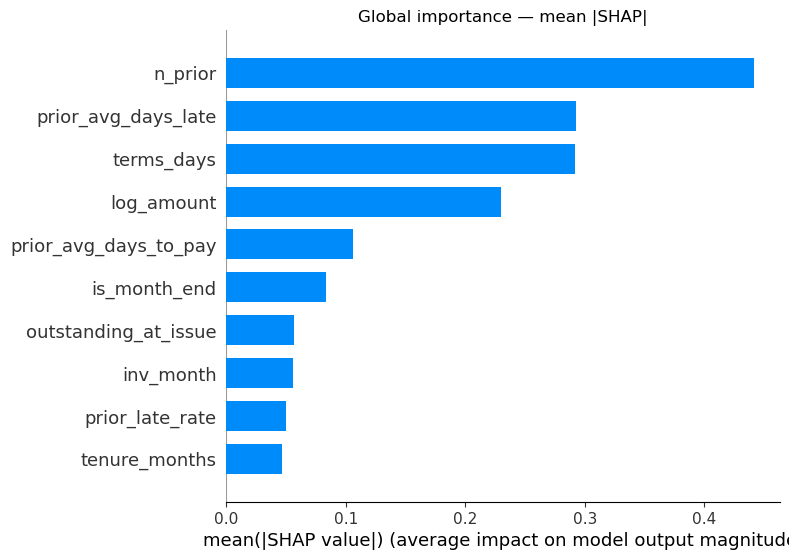

In [95]:
shap.summary_plot(sv, sample[feats], plot_type="bar", show=False, max_display=10)
plt.title("Global importance — mean |SHAP|")

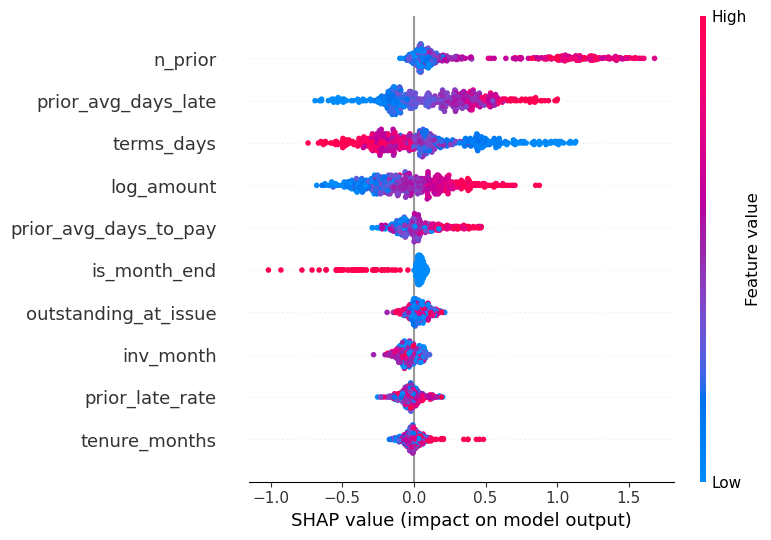

In [96]:
shap.summary_plot(sv, sample[feats], show=False, max_display=10)

Text(0.5, 1.0, 'SHAP dependence: prior late rate')

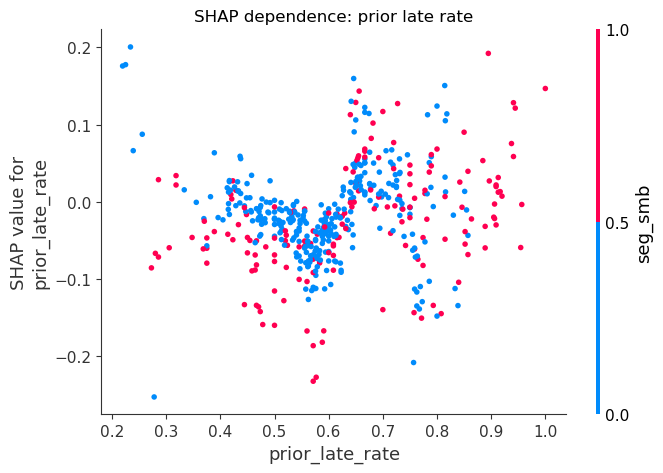

In [97]:
shap.dependence_plot("prior_late_rate", sv, sample[feats], show=False)
plt.title("SHAP dependence: prior late rate")

INV001672 enterprise Rs 208.5 L P(late)= 0.971 actually LATE


<AxesSubplot: >

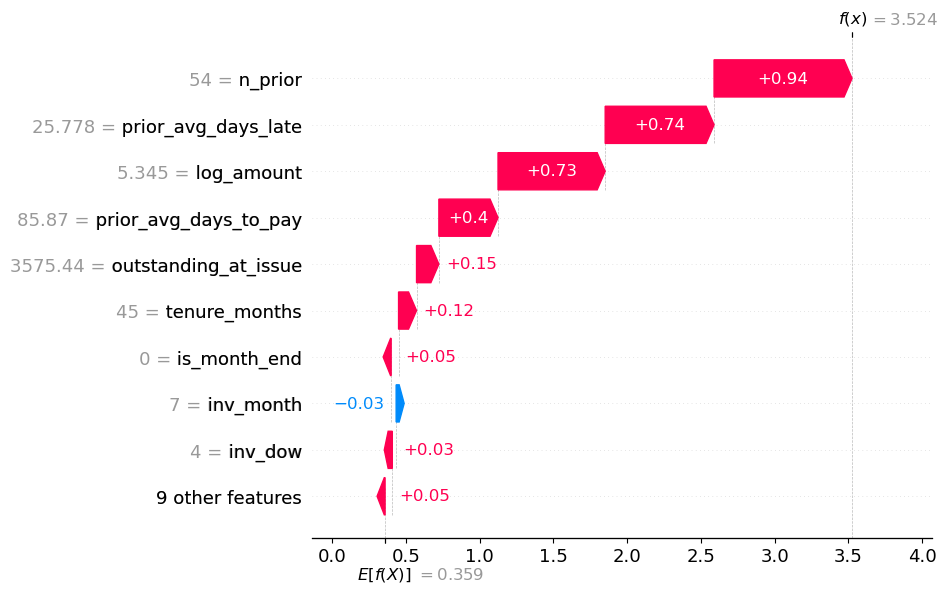

In [98]:
t2 = df[te].copy(); t2["p"] = bclf.predict_proba(df.loc[te, feats])[:, 1]
top = t2.loc[t2["p"].idxmax()]
sv1 = np.asarray(ex.shap_values(df.loc[[top.name], feats])).ravel()
exp = shap.Explanation(values=sv1, base_values=np.asarray(ex.expected_value).ravel()[0],
                       data=df.loc[top.name, feats].values, feature_names=feats)
print(top["invoice_id"], top["segment"], "Rs", round(top["amount_lakh"], 1), "L",
      "P(late)=", round(top["p"], 3), "actually", "LATE" if top["is_late"] else "on time")
shap.plots.waterfall(exp, show=False, max_display=10)

## 12. SQL layer — aging, DSO, collections reporting

In [100]:
import sqlite3
con = sqlite3.connect("data/ar_collections.db")
raw = pd.read_csv("data/ar_invoices.csv")   # raw strings keep SQLite date math simple
raw.to_sql("invoices", con, if_exists="replace", index=False)
print("invoices table ready:", pd.read_sql("SELECT COUNT(*) n FROM invoices", con).iloc[0, 0])

invoices table ready: 10833


In [101]:
pd.read_sql('''SELECT
  CASE WHEN julianday('2025-12-31') - julianday(due_date) <= 0 THEN 'not yet due'
       WHEN julianday('2025-12-31') - julianday(due_date) <= 30 THEN '1-30 days'
       WHEN julianday('2025-12-31') - julianday(due_date) <= 60 THEN '31-60 days'
       ELSE '61+ days' END AS bucket,
  COUNT(*) AS n, ROUND(SUM(amount_lakh), 1) AS out_lakh
FROM invoices WHERE paid_date IS NULL GROUP BY bucket''', con)

        bucket    n  out_lakh
0    1-30 days  220    7558.5
1   31-60 days   61    2469.8
2     61+ days    8     509.0
3  not yet due  632   21586.5

In [102]:
pd.read_sql('''SELECT segment, COUNT(*) AS n,
       ROUND(SUM(amount_lakh), 1) AS out_lakh,
       ROUND(AVG(julianday('2025-12-31') - julianday(due_date)), 0) AS avg_dpd
FROM invoices WHERE paid_date IS NULL
GROUP BY segment ORDER BY out_lakh DESC''', con)

      segment    n  out_lakh  avg_dpd
0  enterprise  401   22575.3    -16.0
1  mid_market  311    7905.1     -8.0
2         smb  209    1643.3     -2.0

In [103]:
pd.read_sql('''SELECT substr(invoice_date, 1, 7) AS ym,
       ROUND(AVG(days_to_pay), 1) AS avg_days_to_pay,
       ROUND(100.0 * AVG(days_late > 0), 1) AS late_pct
FROM invoices WHERE paid_date IS NOT NULL
GROUP BY ym ORDER BY ym''', con).tail(8)

         ym  avg_days_to_pay  late_pct
16  2025-05             63.7      75.5
17  2025-06             65.8      78.6
18  2025-07             64.3      78.3
19  2025-08             62.9      79.5
20  2025-09             59.7      76.8
21  2025-10             50.4      68.9
22  2025-11             37.2      37.7
23  2025-12             20.6      10.5

In [104]:
pd.read_sql('''SELECT customer_id, COUNT(*) AS n_open,
       ROUND(SUM(amount_lakh), 1) AS out_lakh
FROM invoices WHERE paid_date IS NULL
GROUP BY customer_id ORDER BY out_lakh DESC LIMIT 5''', con)

  customer_id  n_open  out_lakh
0       C0052      17    1045.7
1       C0225      12     838.6
2       C0194       7     783.6
3       C0080      11     749.0
4       C0055      14     729.0

## Executive summary
**Findings**
- Payment behavior broke in **April 2025**: vintage late rates jumped 56% → 75%, DSO 55 → 75 days
- **History predicts**: worst prior-late-rate quartile goes late 73% vs 51% for the best; `n_prior` is the top SHAP driver
- **Censoring understates risk**: 66% of Q4-2025 invoices unresolved; naive late-rate 58.7% vs true 62.3%
- **Cash at risk**: ₹26,588L of ₹32,124L outstanding expected late (82.8%); top 10 customers = 23.8% of it; chasing the riskiest 20% captures the majority of late cash
- Model survives the downturn: walk-forward mean AUC 0.67; calibration holds per segment
- Model comparison kept honest: LogReg outranks LightGBM on ROC-AUC (0.69 vs 0.66) —
  the signal is mostly monotone; trees kept for risk bands, interactions, and exact SHAP

**Recommendations**
1. Work the `ar_cash_at_risk` priority list top-down — start with C0052 (₹910L across 17 invoices)
2. Retrain monthly; monitor the money-calibration ratio (April showed 0.73 pre-retrain)
3. Review terms policy: longer terms correlate with lower late rates in the north region
4. Tighten dunning for customers crossing 30 days with high prior late rates